In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from FVM_1D_jan2025 import fvm_1D
from coPINN_1D_Robin_Jan2025 import coPINN_1D_Solver
from vPINN_1D_Robin import vPINN_1D_Solver

from Residuals_1D import pde_res_compare, robin_residual_compare

device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
# device1 = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')
# device2 = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')

In [2]:
torch.pi = torch.acos(torch.zeros(1)).item() * 2
L = 1.0

c_1 = 0.5
c_2 = 5.0

h_c = 0.01
T_a = 300.0

alpha = 0.05
beta = 0.1

C_left = 4
C_right = 0

tol_T = 1e-7
tol_C = 1e-8


def S(T):
    return c_1*(-1.0-np.abs(np.sin(T)))
    # return c_1*(-T/1000.0)

def Q(C):
    # return c_2*(-1 + -1*np.abs(np.cos(C)))
    return c_2*(-1.0 - np.cos(10.0*C))
    # return c_2*(-1.0*np.power(C,1))
    # return c_2*(-1.0 - C)

def S_torch(T):
    # return c_1*(-T/1000.0)
    return c_1*(-1.0-torch.abs(torch.sin(T)))

def Q_torch(C):
    return c_2*(-1.0 - torch.cos(10.0*C))
    # return c_2*(-1.0*torch.pow(C,1))

pde_related_funcs = {"heat_source_func":Q,"heat_source_func_torch":Q_torch,"conc_force_func":S,"conc_force_func_torch":S_torch}

problem_constants = {"L":L,"alpha":alpha,"beta":beta,"h_c":h_c,"T_a":T_a,"C_left":C_left,"C_right":C_right}

In [3]:
N_x_1 = 10 #low must be 500 TAKES APPROX 40 SECONDS
max_time = 30 #seconds

T_FVM_1, C_FVM_1, iters1, eps_T1, eps_C1 = fvm_1D(pde_related_funcs,problem_constants,N_x_1,tol_T,tol_C,max_time)

T_right_fvm1 = T_FVM_1[-1]
T_FVM_1 = T_FVM_1[:-1]

T_FVM_norm_1 = np.linalg.norm(T_FVM_1,2)
C_FVM_norm_1 = np.linalg.norm(C_FVM_1,2)


fvm_results_1 = {'T_FVM': T_FVM_1,'C_FVM':C_FVM_1,"T_FVM_norm":T_FVM_norm_1,"C_FVM_norm":C_FVM_norm_1}

Iter:  10000 eps_T:  0.7096442260971116 eps_C:  0.07130623715054174
Iter:  20000 eps_T:  1.3148356571012982 eps_C:  0.0771708565937157
Iter:  30000 eps_T:  2.560161561240875 eps_C:  0.1676037348689836
Iter:  40000 eps_T:  0.6055887730969971 eps_C:  0.035715542447244175
Iter:  50000 eps_T:  0.12109023537828989 eps_C:  0.006293799708386061
Iter:  60000 eps_T:  0.05719195523039389 eps_C:  0.004459171033890819
Iter:  70000 eps_T:  0.09621217669234738 eps_C:  0.008402457325139778
Iter:  80000 eps_T:  1.2443272285217404 eps_C:  0.09872656806568703
Iter:  90000 eps_T:  1.1251623819136967 eps_C:  0.10359089367013974
Iter:  100000 eps_T:  2.132368379440777 eps_C:  0.1294485456599226
Iter:  110000 eps_T:  0.5586273023638455 eps_C:  0.01371324890775627
Iter:  120000 eps_T:  0.05988568459787302 eps_C:  0.0045798344499101695
Iter:  130000 eps_T:  0.07308986798722117 eps_C:  0.007816756514386736
Iter:  140000 eps_T:  0.15518032983669627 eps_C:  0.004417600850488146
Iter:  150000 eps_T:  0.5754780199

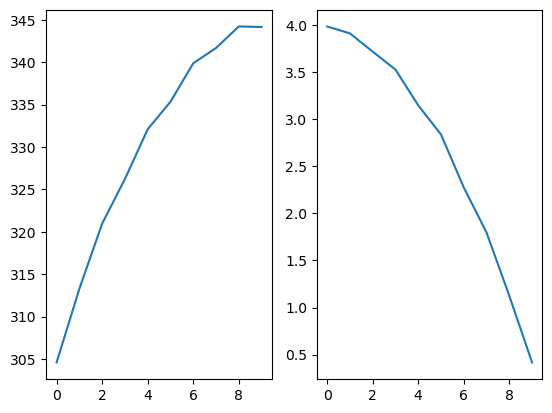

In [4]:
fig,ax = plt.subplots(1,2)
ax[0].plot(T_FVM_1)
ax[1].plot(C_FVM_1)

In [5]:
N_x_2 = 100 #Medium TAKES APPROX 3 Minutes
max_time = 30 #seconds

T_FVM_2, C_FVM_2, iters2, eps_T2,eps_C2 = fvm_1D(pde_related_funcs,problem_constants,N_x_2,tol_T,tol_C,max_time)


T_FVM_norm_2 = np.linalg.norm(T_FVM_2,2)
C_FVM_norm_2 = np.linalg.norm(C_FVM_2,2)

T_right_fvm2 = T_FVM_2[-1]
T_FVM_2 = T_FVM_2[:-1]


fvm_results_2 = {'T_FVM': T_FVM_2,'C_FVM':C_FVM_2,"T_FVM_norm":T_FVM_norm_2,"C_FVM_norm":C_FVM_norm_2}

Iter:  10000 eps_T:  0.011088098880918551 eps_C:  3.8422361635315205e-05
Iter:  20000 eps_T:  0.0031869221055558228 eps_C:  4.80631427455247e-05
Iter:  30000 eps_T:  0.0009164742366465362 eps_C:  1.4620077514848617e-05
Iter:  40000 eps_T:  0.00026088446685434974 eps_C:  3.291518732462251e-06
Iter:  50000 eps_T:  7.577686068316325e-05 eps_C:  1.1182646819651865e-06
Iter:  60000 eps_T:  2.005334619070709e-05 eps_C:  1.7891642423162324e-07
Iter:  70000 eps_T:  5.306277614636201e-06 eps_C:  7.895120535117428e-08
Iter:  80000 eps_T:  1.436933303011756e-06 eps_C:  2.3169501872644105e-08
Iter:  90000 eps_T:  3.954642693315691e-07 eps_C:  6.772781446784393e-09
Iter:  100000 eps_T:  1.0686346740840236e-07 eps_C:  1.8121326661457715e-09
Elapsed Time 1.743356


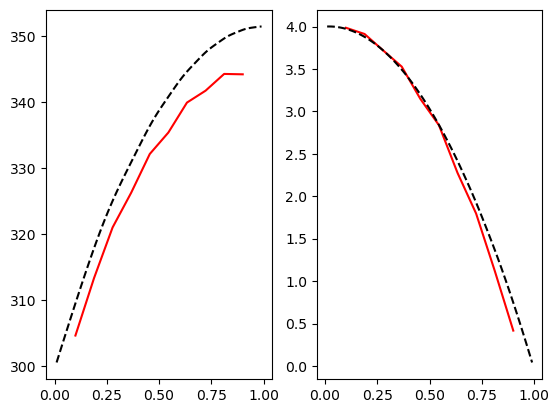

In [6]:
fig,ax = plt.subplots(1,2)
x_1 = np.linspace(0+L/N_x_1,L-L/N_x_1,N_x_1).reshape(-1,1)
x_2 = np.linspace(0+L/N_x_2,L-L/N_x_2,N_x_2).reshape(-1,1)


ax[0].plot(x_1,T_FVM_1,'r')
ax[0].plot(x_2,T_FVM_2,'k--')
ax[1].plot(x_1,C_FVM_1,'r')
ax[1].plot(x_2,C_FVM_2,'k--')

In [7]:
np.max(T_FVM_2)

np.float64(351.40374124367264)

In [8]:
import h5py 

folder ='./FVM_Result_Storage/'

opt = "w" #"r" or "w"

with h5py.File(folder+'FVM_latest.h5',opt) as hf:

    if(opt == "w"):
        FVM1_grp = hf.create_group("FVM_1")
        FVM1_grp.create_dataset('T_FVM',data = T_FVM_1)
        FVM1_grp.create_dataset('C_FVM',data = C_FVM_1)
        FVM1_grp.create_dataset('iters',data = iters1)
        FVM1_grp.create_dataset('eps_T',data = eps_T1)
        FVM1_grp.create_dataset('eps_C',data = eps_C1)

        FVM2_grp = hf.create_group("FVM_2")
        FVM2_grp.create_dataset('T_FVM',data = T_FVM_2)
        FVM2_grp.create_dataset('C_FVM',data = C_FVM_2)
        FVM2_grp.create_dataset('iters',data = iters2)
        FVM2_grp.create_dataset('eps_T',data = eps_T2)
        FVM2_grp.create_dataset('eps_C',data = eps_C2) 

    if(opt == "r"):
        FVM1_grp = hf['FVM_1']
        T_FVM_1 = FVM1_grp['T_FVM'][:]
        C_FVM_1 = FVM1_grp['C_FVM'][:]
        iters1 = FVM1_grp['iters'][:]
        eps_T1 = FVM1_grp['eps_T'][:]
        eps_C1 = FVM1_grp['eps_C'][:]

        FVM2_grp = hf['FVM_2']
        T_FVM_2 = FVM2_grp['T_FVM'][:]
        C_FVM_2 = FVM2_grp['C_FVM'][:]
        iters2 = FVM2_grp['iters'][:]
        eps_T2 = FVM2_grp['eps_T'][:]
        eps_C2 = FVM2_grp['eps_C'][:]



    # hf.create_dataset('T_FVM_1',data = T_FVM_1)
    # hf.create_dataset('C_FVM_1',data = C_FVM_1)

In [9]:
# with h5py.File(folder + "FVM_latest.h5", "r") as f:
#     print("Keys: %s" % f.keys())

#     a_group_key = list(f.keys())[0]

#     # get the object type for a_group_key: usually group or dataset
#     print(type(f[a_group_key])) 
#     data = list(f[a_group_key])

In [10]:
optimizer_algo = "LBFGS" #or Adam
# optimizer_algo = "Adam"
max_iter = 100 #200
# max_iter = 5000

N_f = 10000  #Total number of collocation points 

layers1 = np.array([1,50,50,50,1]) #9 hidden layers
layers2 = np.array([1,50,50,50,1]) #9 hidden layers

coPINN_constants = {"N_f":N_f,"max_iter" :max_iter,"layers1":layers1,"layers2":layers2,
                    "optimizer_algo":optimizer_algo,"device":device,"fvm_results":fvm_results_2}

In [17]:
coPINN_solver = coPINN_1D_Solver(coPINN_constants,pde_related_funcs,problem_constants,N_x_2)
coPINN_trained,train_hist = coPINN_solver.train_model(123)

Sequentialmodel(
  (activation): Tanh()
  (loss_function): MSELoss()
  (linears1): ModuleList(
    (0): Linear(in_features=1, out_features=50, bias=True)
    (1-2): 2 x Linear(in_features=50, out_features=50, bias=True)
    (3): Linear(in_features=50, out_features=1, bias=True)
  )
  (linears2): ModuleList(
    (0): Linear(in_features=1, out_features=50, bias=True)
    (1-2): 2 x Linear(in_features=50, out_features=50, bias=True)
    (3): Linear(in_features=50, out_features=1, bias=True)
  )
)
123
0 Train Loss 709.0446 RD T: 0.555940816504247 RD C: 1.901260140425022
1 Train Loss 121.95838 RD T: 0.05455111383131341 RD C: 1.5438832483185567
2 Train Loss 23.030565 RD T: 0.06315440928592386 RD C: 0.25125551153770925
3 Train Loss 17.076145 RD T: 0.05063147672768091 RD C: 0.20263703363950447
4 Train Loss 13.252535 RD T: 0.04333864296670025 RD C: 0.13248939178722613
5 Train Loss 9.676062 RD T: 0.0462453047540267 RD C: 0.07715828408768494
6 Train Loss 8.407441 RD T: 0.03629009971449873 RD C: 0

In [18]:
T_coPINN,C_coPINN = coPINN_trained.test()
# T_PINN = T_PINN.reshape(s[0],s[1])
# C_PINN = C_PINN.reshape(s[0],s[1])

In [13]:
optimizer_algo = "LBFGS" #or Adam
# optimizer_algo = "Adam"
max_iter = 100 #200
# max_iter = 5000

N_f = 10000  #Total number of collocation points 

layers = np.array([1,64,64,64,64,64,64,2]) #9 hidden layers


vPINN_constants = {"N_f":N_f,"max_iter" :max_iter,"layers":layers,"optimizer_algo":optimizer_algo,"device":device,"fvm_results":fvm_results_2}

In [ ]:
vPINN_solver = vPINN_1D_Solver(vPINN_constants,pde_related_funcs,problem_constants,N_x_2)
vPINN_trained,train_hist_vP = vPINN_solver.train_model(121)

Sequentialmodel(
  (activation): Tanh()
  (loss_function): MSELoss()
  (linears): ModuleList(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1-5): 5 x Linear(in_features=64, out_features=64, bias=True)
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)
121
0 Train Loss 1038.0138 RD T: 0.6582561386990494 RD C: 1.3210652132158367
1 Train Loss 303.34897 RD T: 0.3313351066517572 RD C: 1.3174022705633837
2 Train Loss 60.18977 RD T: 0.12211853989391729 RD C: 0.5772883278703294
3 Train Loss 43.98856 RD T: 0.1158276155382209 RD C: 0.4518698874648339
4 Train Loss 32.777233 RD T: 0.11416968381777923 RD C: 0.23054814952891606
5 Train Loss 30.026926 RD T: 0.10921347776669374 RD C: 0.2161304881760238
6 Train Loss 29.701204 RD T: 0.11001110722891667 RD C: 0.20914771744947688
7 Train Loss 29.46196 RD T: 0.10987079290213647 RD C: 0.20892784819487212
8 Train Loss 29.367641 RD T: 0.11016976095111872 RD C: 0.20976821169370707
9 Train Loss 28.972256 RD T: 0.1119715836192247 

In [ ]:
# train_hist_vP = vPINN_trained[1]
# vPINN_trained = vPINN_trained[0]
T_vPINN,C_vPINN = vPINN_trained.test()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


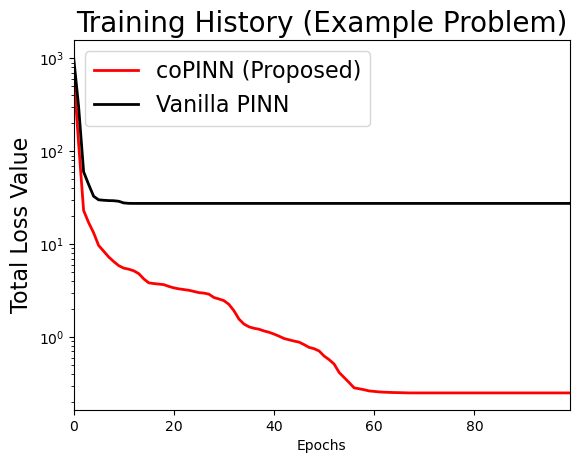

In [29]:
fig,ax = plt.subplots()

ax.plot(train_hist,'r',label = 'coPINN (Proposed)',linewidth = 2)
ax.plot(train_hist_vP,'k',label = 'Vanilla PINN',linewidth = 2)

ax.set_xlabel('Epochs')
ax.set_ylabel('Total Loss Value',math_fontfamily = 'cm',fontsize = 16)
ax.set_title('Training History (Example Problem)',fontsize = 20)
ax.legend(loc = 2,fontsize = 16)

ax.set_xlim([0,99])
# ax.set_ylim([2.5,10000])
ax.set_yscale('log')

formats = ['pdf','svg','png','eps']

for format in formats:
    folder = './Plots/'+format + '/'
    fig.savefig(folder+'Train_hist.'+format,format = format,bbox_inches = 'tight')

In [ ]:
# import h5py 

# folder ='./FVM_Result_Storage/'

# with h5py.File(folder+'FVM_1_' + str(N_x_1)+
#                '.h5','w') as hf:
#     hf.create_dataset('T_FVM_1',data = T_FVM_1)
#     hf.create_dataset('C_FVM_1',data = C_FVM_1)

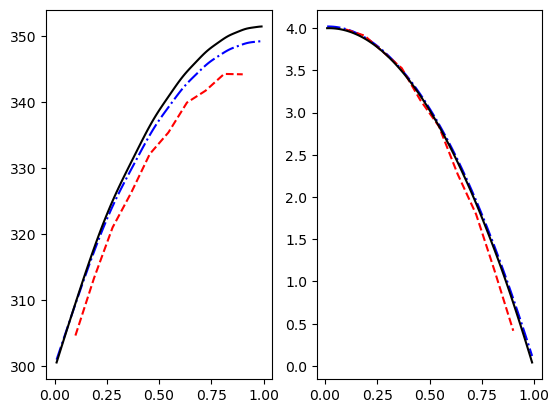

In [24]:

fig,ax = plt.subplots(1,2)

ax[0].plot(x_2,T_coPINN,'b-.')
ax[0].plot(x_1,T_FVM_1,'r--')
ax[0].plot(x_2,T_FVM_2,'k-')
# ax[0].plot(x_2000,T_FVM_3,'g')

ax[1].plot(x_2,C_coPINN,'b-.')
ax[1].plot(x_1,C_FVM_1,'r--')
ax[1].plot(x_2,C_FVM_2,'k-')
# ax[1].plot(x_2000,C_FVM_3,'g')

In [25]:


def insert_left_right(arr,left,right):
    arr = np.insert(arr,0,left)
    arr = np.append(arr,right)

    return arr

def np_to_torch(arr,device):
    return torch.from_numpy(arr.reshape(-1,1)).float().to(device)

x_2_full = insert_left_right(x_2,0.0,1.0)
x_1_full = insert_left_right(x_1,0.0,1.0)
T_FVM_1_full = insert_left_right(T_FVM_1,300.0,T_right_fvm1)
T_FVM_2_full = insert_left_right(T_FVM_2,300.0,T_right_fvm2)
C_FVM_1_full = insert_left_right(C_FVM_1,C_left,C_right)
C_FVM_2_full = insert_left_right(C_FVM_2,C_left,C_right)
T_coPINN = coPINN_trained.forward1(np_to_torch(x_2_full,device)).cpu().detach().numpy()
C_coPINN = coPINN_trained.forward2(np_to_torch(x_2_full,device)).cpu().detach().numpy()
T_vPINN = vPINN_trained.forward(np_to_torch(x_2_full,device))[:,0:1].cpu().detach().numpy()
C_vPINN = vPINN_trained.forward(np_to_torch(x_2_full,device))[:,1:2].cpu().detach().numpy()

In [26]:
np.sqrt(np.mean(np.square(T_FVM_2_full - T_vPINN.reshape(-1,))))

np.float64(37.67488662905487)

In [27]:
T_vPINN

array([[299.2478 ],
       [299.17303],
       [299.1026 ],
       [299.03574],
       [298.97232],
       [298.91257],
       [298.8562 ],
       [298.80344],
       [298.7543 ],
       [298.7086 ],
       [298.6664 ],
       [298.6277 ],
       [298.59247],
       [298.56067],
       [298.5324 ],
       [298.50742],
       [298.4859 ],
       [298.46774],
       [298.45288],
       [298.44122],
       [298.4328 ],
       [298.42764],
       [298.42554],
       [298.42654],
       [298.4306 ],
       [298.4376 ],
       [298.44757],
       [298.4603 ],
       [298.4758 ],
       [298.4941 ],
       [298.51495],
       [298.5384 ],
       [298.5642 ],
       [298.59244],
       [298.62302],
       [298.65573],
       [298.69055],
       [298.72748],
       [298.76624],
       [298.80673],
       [298.849  ],
       [298.89285],
       [298.93817],
       [298.98486],
       [299.03278],
       [299.0819 ],
       [299.13202],
       [299.18307],
       [299.23483],
       [299.28735],


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


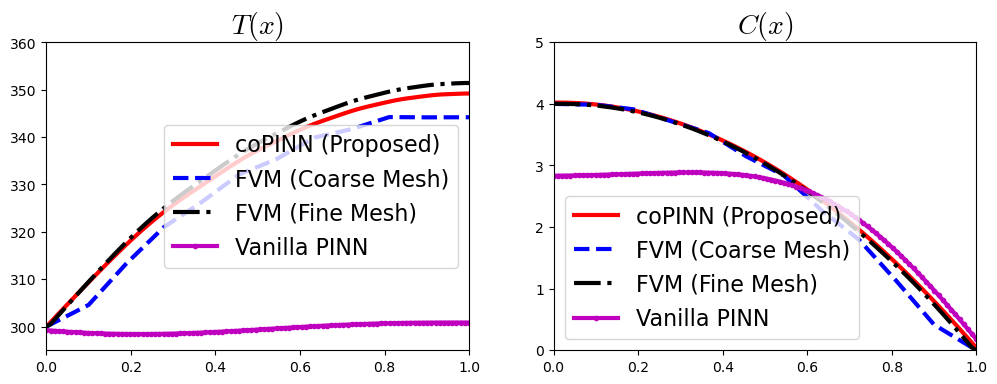

In [28]:

fig, ax = plt.subplots(1,2)

fig.set_size_inches(12,4)

lw = 3 

ax[0].plot(x_2_full,T_coPINN,'r-',label = 'coPINN (Proposed)',linewidth = lw)
ax[0].plot(x_1_full,T_FVM_1_full,'b--',label = 'FVM (Coarse Mesh)',linewidth = lw)
ax[0].plot(x_2_full,T_FVM_2_full,'k-.',label = 'FVM (Fine Mesh)',linewidth = lw)
ax[0].plot(x_2_full,T_vPINN,'m.-',label = 'Vanilla PINN',linewidth = lw)

ax[0].set_title('$T(x)$', math_fontfamily = 'cm',fontsize = 20)
ax[0].legend(fontsize = 16)
ax[0].set_xlim([0,1])
ax[0].set_ylim([295,360])
# ax[0].plot(x_2000,T_FVM_3,'g')



ax[1].plot(x_2_full,C_coPINN,'r-',label = 'coPINN (Proposed)',linewidth = lw)
ax[1].plot(x_1_full,C_FVM_1_full,'b--',label = 'FVM (Coarse Mesh)',linewidth = lw)
ax[1].plot(x_2_full,C_FVM_2_full,'k-.',label = 'FVM (Fine Mesh)',linewidth = lw)
ax[1].plot(x_2_full,C_vPINN,'m.-',label = 'Vanilla PINN',linewidth = lw)

ax[1].set_title('$C(x)$', math_fontfamily = 'cm', fontsize = 20)
ax[1].legend(fontsize = 16)
ax[1].set_xlim([0,1])
ax[1].set_ylim([0,5])
# fig.tight_layout()

save_name = 'Preds_1D'
formats = ['svg','png','eps','pdf']
folder_base = './Plots/'
folders = ['svg/','png/','eps/','pdf/']

for format in formats:
    fig.savefig(folder_base + format + '/' + save_name+'.'+format,
                format = format,bbox_inches = 'tight',transparent=True)

In [50]:
from scipy.interpolate import CubicSpline

In [51]:
opt = 'neutral' #'grid' or 'neutral'
interp_method = "cubic spline"
N_x_test = N_x_2

T_left = T_a


f1_coPINN,f1_fvm1,f2_coPINN,f2_fvm1, x_test1 = pde_res_compare(opt,interp_method, pde_related_funcs,
                problem_constants, N_x_test, 
                N_x_1, T_FVM_1,C_FVM_1,T_right_fvm1,T_left,C_right,C_left,
                coPINN_trained,device)

f1_coPINN,f1_fvm2,f2_coPINN,f2_fvm2, x_test2 = pde_res_compare(opt,interp_method, pde_related_funcs,
                problem_constants, N_x_test, 
                N_x_2, T_FVM_2,C_FVM_2,T_right_fvm2,T_left,C_right,C_left,
                coPINN_trained,device)


print('##########################################')

f1_vPINN,f1_fvm1,f2_vPINN,f2_fvm1, x_test1 = pde_res_compare(opt,interp_method, pde_related_funcs,
                problem_constants, N_x_test, 
                N_x_1, T_FVM_1,C_FVM_1,T_right_fvm1,T_left,C_right,C_left,
                vPINN_trained,device)

f1_vPINN,f1_fvm2,f2_vPINN,f2_fvm2, x_test2 = pde_res_compare(opt,interp_method, pde_related_funcs,
                problem_constants, N_x_test, 
                N_x_2, T_FVM_2,C_FVM_2,T_right_fvm2,T_left,C_right,C_left,
                vPINN_trained,device)

PINN_f1: 0.1503
FVM_f1: 6.9413
PINN_f2: 0.1473
FVM_f2: 0.9663
PINN_f1: 0.1404
FVM_f1: 0.1511
PINN_f2: 0.1489
FVM_f2: 0.1245
##########################################
PINN_f1: 4.2226
FVM_f1: 6.3348
PINN_f2: 0.5739
FVM_f2: 0.8777
PINN_f1: 3.6845
FVM_f1: 0.3569
PINN_f2: 0.5240
FVM_f2: 0.0522


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


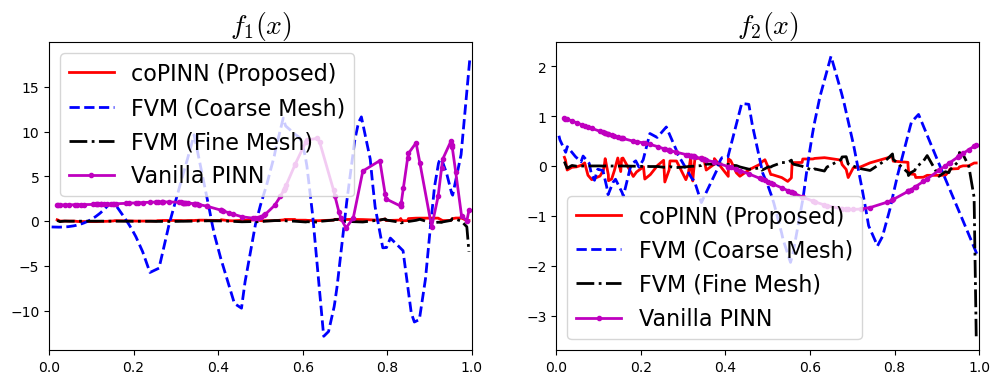

In [61]:
fig, ax = plt.subplots(1,2)

fig.set_size_inches(12,4)

lw = 2

ax[0].plot(x_test2,f1_coPINN,'r-',label = 'coPINN (Proposed)',linewidth = lw)
ax[0].plot(x_test1,f1_fvm1,'b--',label = 'FVM (Coarse Mesh)',linewidth = lw)
ax[0].plot(x_test2,f1_fvm2,'k-.',label = 'FVM (Fine Mesh)',linewidth = lw)
ax[0].plot(x_test2,f1_vPINN,'m.-',label = 'Vanilla PINN',linewidth = lw)

ax[0].set_title('$f_1(x)$', math_fontfamily = 'cm',fontsize = 20)
ax[0].legend(fontsize = 16)
ax[0].set_xlim([0,1])
# ax[0].set_ylim([300,360])
# ax[0].plot(x_2000,T_FVM_3,'g')

ax[1].plot(x_test2,f2_coPINN,'r-',label = 'coPINN (Proposed)',linewidth = lw)
ax[1].plot(x_test1,f2_fvm1,'b--',label = 'FVM (Coarse Mesh)',linewidth = lw)
ax[1].plot(x_test2,f1_fvm2,'k-.',label = 'FVM (Fine Mesh)',linewidth = lw)
ax[1].plot(x_test2,f2_vPINN,'m.-',label = 'Vanilla PINN',linewidth = lw)

ax[1].set_title('$f_2(x)$', math_fontfamily = 'cm', fontsize = 20)
ax[1].legend(fontsize = 16)
ax[1].set_xlim([0,1])
# ax[1].set_ylim([0,5])
# fig.tight_layout()

save_name = 'Residuals_1D'
formats = ['svg','png','eps','pdf']
folder_base = './Plots/'
folders = ['svg/','png/','eps/','pdf/']

for format in formats:
    fig.savefig(folder_base + format + '/' + save_name+'.'+format,
                format = format,bbox_inches = 'tight',transparent=True)

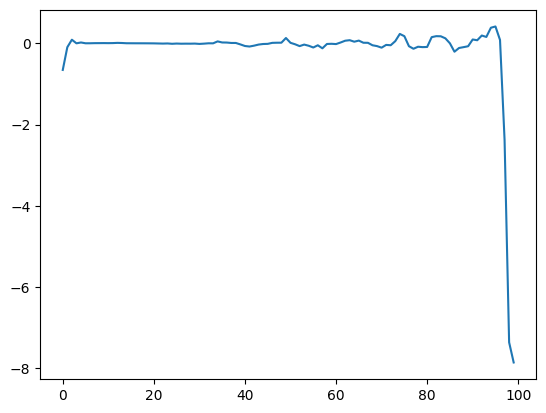

In [35]:
r_fvm1, r_coPINN = robin_residual_compare(problem_constants, N_x_1,T_FVM_1,T_right_fvm1,T_left,coPINN_trained,device)

r_fvm2, r_coPINN = robin_residual_compare(problem_constants, N_x_2,T_FVM_2,T_right_fvm2,T_left,coPINN_trained,device)


r_fvm1, r_vPINN = robin_residual_compare(problem_constants, N_x_1,T_FVM_1,T_right_fvm1,T_left,vPINN_trained,device)

r_fvm2, r_vPINN = robin_residual_compare(problem_constants, N_x_2,T_FVM_2,T_right_fvm2,T_left,vPINN_trained,device)


print("Robin Residuals f1:",r_fvm1)
print("Robin Residuals f2:",r_fvm2)
print("Robin Residuals coPINN:",r_coPINN)
print("Robin Residuals vPINN:",r_vPINN)



Robin Residuals f1: 11.210438680812137
Robin Residuals f2: 1.6411002825766814
Robin Residuals coPINN: [[0.01234606]]
Robin Residuals vPINN: [[0.24513088]]


In [ ]:
#PINN's Dirichlet residuals
res_T_left = coPINN_trained.forward1(torch.tensor([[0.0]]).to(device))-T_left
res_C_left = coPINN_trained.forward2(torch.tensor([[0.0]]).to(device))-C_left
res_C_right = coPINN_trained.forward2(torch.tensor([[L]]).to(device))-C_right

print("Dirichlet Residuals T_left:",res_T_left.item())
print("Dirichlet Residuals C_left:",res_C_left.item())
print("Dirichlet Residuals C_right:",res_C_right.item()) 

Dirichlet Residuals T_left: 0.00262451171875
Dirichlet Residuals C_left: 0.0032792091369628906
Dirichlet Residuals C_right: 0.011780709028244019


In [34]:
#PINN's Dirichlet residuals
res_T_left = vPINN_trained.forward(torch.tensor([[0.0]]).to(device))[0,0]-T_left
res_C_left = vPINN_trained.forward(torch.tensor([[0.0]]).to(device))[0,1]-C_left
res_C_right = vPINN_trained.forward(torch.tensor([[L]]).to(device))[0,1]-C_right

print("Dirichlet Residuals T_left:",res_T_left.item())
print("Dirichlet Residuals C_left:",res_C_left.item())
print("Dirichlet Residuals C_right:",res_C_right.item()) 

Dirichlet Residuals T_left: -0.3720703125
Dirichlet Residuals C_left: -1.9670994281768799
Dirichlet Residuals C_right: 0.35580331087112427
